# Forecasting `Ziekteverzuimpercentage` — Seasonal Baseline vs Naive Seasonal

A minimal end-to-end pipeline that forecasts the national quarterly sickness-absence rate (`Ziekteverzuimpercentage_1`) and compares a 3-year seasonal moving-average baseline against a 1-year naive seasonal benchmark. Both models rely only on the target's own history, using observations from at least one year earlier.

## Approach

**Data.** A single quarterly time series (1996 Q1 onward, 120 observations) of the Dutch national sickness-absence rate, pulled from the gold-layer table `master_data_ml_preprocessed`.

**Lookback structure.** Each prediction uses observations from at least one year earlier — Model A uses only `y_{t-4}`, Model B averages `y_{t-4}`, `y_{t-8}`, and `y_{t-12}`.

**Hold-out window.** Chronological, *not* random — random splits would leak future information into the look-back history. The last **4 quarters** are held out for evaluation. The 12 earlier quarters are not a training set in the parameter-fitting sense (neither model has parameters to fit); they are just the source of past observations the models look back into.

**Models.**
- **A — Naive seasonal baseline:** `ŷ_t = y_{t-4}` (same quarter, one year earlier). The one-year analogue of Model A — a useful sanity check on whether averaging across three years helps or hurts.
- **B — Seasonal moving-average baseline:** `ŷ_t = mean(y_{t-4}, y_{t-8}, y_{t-12})` (same quarter, averaged over the previous three years). A simple baseline that smooths over year-to-year noise while preserving seasonality.

**Evaluation.** MAE, RMSE and R² on the 12-quarter hold-out, plus a visual actual-vs-predicted plot. The interesting question: does the 3-year moving average (B) actually improve on the 1-year look-up (A)?

## 1 · Environment setup

Imports the project's data and plotting stack, wires the repo root into `sys.path` so that `from src.*` works inside the notebook, and pulls the two project-wide constants we rely on — the path to the gold SQLite database and the name of the target column.

In [1]:
import sys
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker

# Make src/ importable from notebook context
PROJECT_ROOT = Path().resolve().parent.parent
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

from src.config import DIR_DB_GOLD, ML_TARGET_COLUMN

print(f"Project root : {PROJECT_ROOT}")
print(f"Gold DB      : {DIR_DB_GOLD}")
print(f"Target column: {ML_TARGET_COLUMN}")

Project root : C:\Users\User\Documents\GitHub\eaisi-uwv
Gold DB      : C:\Users\User\Documents\GitHub\eaisi-uwv\data\3_gold\gold_data.db
Target column: Ziekteverzuimpercentage_1


## 2 · Extract the target series

Instantiates `DataExtractor` against the `master_data_ml_preprocessed` table and pulls a flat DataFrame. The result `df_raw` has one row per quarter at the national / all-industry level. From this DataFrame only the target column `Ziekteverzuimpercentage_1` is used downstream.

In [2]:
from src.ml_engineering.ml_1_data_extraction import DataExtractor

extractor = DataExtractor(db_path=DIR_DB_GOLD, table_name="master_data_ml_preprocessed")
df_raw = extractor.extract(target_column=ML_TARGET_COLUMN, feature_groups=None)  # discovery: all columns

print(f"Shape: {df_raw.shape[0]} rows × {df_raw.shape[1]} columns")
df_raw.head(5)

⚙️ SBI mode=all-industry (BedrijfskenmerkenSBI2008_T001081) | 120 quarterly rows
✅ Extraction complete | mode=discovery | sbi=all-industry | features=61 | rows=120


Shape: 120 rows × 65 columns


,period_enddate,year,quarter,Ziekteverzuimpercentage_1,trend_index,Banen_2_A045285_3000,Banen_2_A045285_4000,Banen_2_A045286_3000,Banen_2_A045286_4000,Banen_7_A045285_3000,...,GewerkteUren_5_A045285,GewerkteUren_5_A045286,WerkzamePersonenSeizoengecorrigeerd_2_A045285,WerkzamePersonenSeizoengecorrigeerd_2_A045286,WerkzamePersonenSeizoengecorrigeerd_9_A045285,WerkzamePersonenSeizoengecorrigeerd_9_A045286,WerkzamePersonen_1_A045285,WerkzamePersonen_1_A045286,WerkzamePersonen_7_A045285,WerkzamePersonen_7_A045286
0,1996-03-31 00:00:00.000000,1996.0,1.0,5.5,1.0,4295.0,3895.0,1098.0,1088.5,4296.0,...,216.866667,44.733333,589.733333,102.600000,0.800000,-0.066667,582.933333,102.000000,13.200000,0.733333
1,1996-06-30 00:00:00.000000,1996.0,2.0,4.6,2.0,4295.0,3895.0,1098.0,1088.5,4296.0,...,202.733333,46.600000,594.066667,102.600000,4.333333,0.066667,596.466667,102.733333,15.200000,0.266667
2,1996-09-30 00:00:00.000000,1996.0,3.0,4.0,3.0,4295.0,3895.0,1098.0,1088.5,4296.0,...,198.866667,43.866667,597.866667,102.733333,3.800000,0.266667,604.133333,102.866667,14.800000,0.400000
3,1996-12-31 00:00:00.000000,1996.0,4.0,4.7,4.0,4295.0,3895.0,1098.0,1088.5,4296.0,...,236.600000,48.133333,602.333333,103.600000,4.533333,0.800000,600.200000,103.666667,12.866667,0.666667
4,1997-03-31 00:00:00.000000,1997.0,1.0,4.9,5.0,4295.0,3895.0,1098.0,1088.5,4296.0,...,220.466667,45.133333,607.200000,104.800000,4.866667,1.066667,600.200000,104.600000,17.333333,2.600000


## 3 · Modelling imports

The three `sklearn` metric helpers (`mean_absolute_error`, `mean_squared_error`, `r2_score`) used for evaluation. Both models in this notebook are pure historical look-ups — no estimator class needed.

In [3]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

## 4 · Build a time-ordered DataFrame

Copies `df_raw`, converts `period_enddate` to a real `pandas.Timestamp` column, sorts the rows chronologically, and promotes the date column to the **DatetimeIndex** of `df`. From here on `df` is the canonical, time-ordered version of the data — needed for honest chronological splits and time-axis plots.

In [4]:
# Sort chronologically and set a proper DatetimeIndex (needed for time-aware splits and plots).
df = df_raw.copy()
df["period_enddate"] = pd.to_datetime(df["period_enddate"])
df = df.sort_values("period_enddate").set_index("period_enddate")

print(f"Rows       : {len(df)}")
print(f"Date range : {df.index.min().date()} → {df.index.max().date()}")

Rows       : 120
Date range : 1996-03-31 → 2025-12-31


## 5 · Define the target series and hold-out window

Extracts the target as a 1-D series `y_full` and isolates the last **12 quarters (3 years)** as the evaluation window `y_test`. There is no parameter fitting in this notebook — both models read `y_full` directly and shift, so the earlier portion of the series serves only as a source of past actuals to look back into, not as a training set in the usual sense.

The hold-out window is purely positional (`y_full.iloc[-TEST_SIZE:]`) because the index is already time-ordered — no shuffling, no random seed.

In [5]:
# Hold-out window: last 12 quarters (3 years) are scored.
# Both seasonal baselines read y_full continuously via .shift(); there is no
# separate "training" slice — the earlier quarters are just past observations
# the models look back into when forming predictions for y_test.
TEST_SIZE = 12

y_full = df[ML_TARGET_COLUMN]
y_test = y_full.iloc[-TEST_SIZE:]

print(f"Full series: {len(y_full)} quarters  ({y_full.index.min().date()} → {y_full.index.max().date()})")
print(f"Hold-out   : {len(y_test)} quarters  ({y_test.index.min().date()} → {y_test.index.max().date()})")

Full series: 120 quarters  (1996-03-31 → 2025-12-31)
Hold-out   : 12 quarters  (2023-03-31 → 2025-12-31)


## 6 · Model A — Seasonal moving-average baseline

A simple seasonal baseline: predict each test quarter as the **mean of the same quarter over the previous three years** — `ŷ_t = mean(y_{t-4}, y_{t-8}, y_{t-12})`. No fitting. Averaging across three years smooths over single-year shocks (e.g. the COVID-era spike) while still preserving the quarterly seasonal pattern.

In [ ]:
# ── Model A: Seasonal moving-average baseline (3-year same-quarter mean) ──
# Prediction for quarter t = mean(y_{t-4}, y_{t-8}, y_{t-12}).
LAGS_SMA = [4, 8, 12]
y_pred_sma = (
    pd.concat([y_full.shift(k) for k in LAGS_SMA], axis=1)
      .mean(axis=1)
      .iloc[-TEST_SIZE:]
)

print(f"Seasonal-MA predictions for the last {TEST_SIZE} quarters:")
print(pd.DataFrame(
    {"actual": y_test.values, "sma_pred": y_pred_sma.round(3).values},
    index=y_test.index,
))

Seasonal-MA predictions for the last 12 quarters:
                actual  sma_pred
period_enddate                  
2023-03-31         5.7     5.433
2023-06-30         5.0     4.867
2023-09-30         4.8     4.667
2023-12-31         5.5     5.300
2024-03-31         5.5     5.600
2024-06-30         5.1     5.033
2024-09-30         4.9     4.800
2024-12-31         5.4     5.500
2025-03-31         5.8     5.833
2025-06-30         5.2     5.167
2025-09-30         5.1     4.900
2025-12-31         5.6     5.500


## 7 · Model B — Naive seasonal model

The cheapest possible forecast: predict each test quarter as the value of the *same quarter one year earlier* (`y_pred = y.shift(4)`). No fitting — just a single-year historical look-up. It's the one-year analogue of Model A and a useful sanity check: if a 1-year look-up beats a 3-year average, the series is shifting level faster than the average can track.

In [18]:
# ── Model B: Naive seasonal baseline (same quarter, one year earlier) ────
# Prediction for quarter t = actual value at quarter t-4.
y_pred_naive = y_full.shift(4).iloc[-TEST_SIZE:]

print(f"Naive predictions for the last {TEST_SIZE} quarters:")
print(pd.DataFrame({"actual": y_test.values, "naive_pred": y_pred_naive.values}, index=y_test.index))

Naive predictions for the last 12 quarters:
                actual  naive_pred
period_enddate                    
2023-03-31         5.7         6.3
2023-06-30         5.0         5.4
2023-09-30         4.8         5.0
2023-12-31         5.5         5.6
2024-03-31         5.5         5.7
2024-06-30         5.1         5.0
2024-09-30         4.9         4.8
2024-12-31         5.4         5.5
2025-03-31         5.8         5.5
2025-06-30         5.2         5.1
2025-09-30         5.1         4.9
2025-12-31         5.6         5.4


## 8 · Hold-out metrics

Computes MAE, RMSE and R² for both models on the 12-quarter hold-out and prints them as a single comparison table. The interesting question: does the 3-year moving average (A) improve on the 1-year look-up (B)?

What each metric means:

**MAE** (Mean Absolute Error) — average absolute distance between prediction and truth, in the same units as the target (percentage points). e.g. an MAE of 0.20 pp means "on average we miss the true sickness-absence rate by 0.20 percentage points." Lower is better.

**RMSE** (Root Mean Squared Error) — same units as the target, but squares errors before averaging, so it punishes big misses much harder than MAE. RMSE ≥ MAE always; a large gap signals a few large errors rather than uniformly small ones.

**R²** — share of the variance in the test target explained by the model, relative to just predicting the test mean. R² = 1 is perfect, R² = 0 means "no better than guessing the mean", negative R² means worse than guessing the mean.

In [19]:
def score(y_true, y_pred):
    return {
        "MAE":  mean_absolute_error(y_true, y_pred),
        "RMSE": np.sqrt(mean_squared_error(y_true, y_pred)),
        "R²":   r2_score(y_true, y_pred),
    }

metrics = pd.DataFrame(
    [
        score(y_test, y_pred_sma),
        score(y_test, y_pred_naive),
    ],
    index=[
        "Seasonal MA (3yr same-quarter)",
        "Naive seasonal (y_{t-4})",
    ],
).round(4)

print("Hold-out metrics (last 12 quarters):")
print(metrics.to_string())

Hold-out metrics (last 12 quarters):
                                   MAE    RMSE      R²
Seasonal MA (3yr same-quarter)  0.1222  0.1394  0.8023
Naive seasonal (y_{t-4})        0.2167  0.2614  0.3051


## 9 · Actual vs predicted

A two-panel diagnostic of the 12-quarter hold-out:

- **Top:** the true target in solid black (with one year of pre-hold-out context shown alongside the shaded hold-out window, so the seasonal pattern the baselines are trying to capture is visible), plus the two model predictions as dashed lines with markers. Each legend entry carries the model's MAE for a quick at-a-glance ranking.
- **Bottom:** prediction residuals (`prediction − actual`) over the same 12 quarters, with zero marked. Residuals make systematic bias visible — e.g. a model that's consistently above or below zero, or one that has a big single-quarter miss the aggregate metrics smooth over.

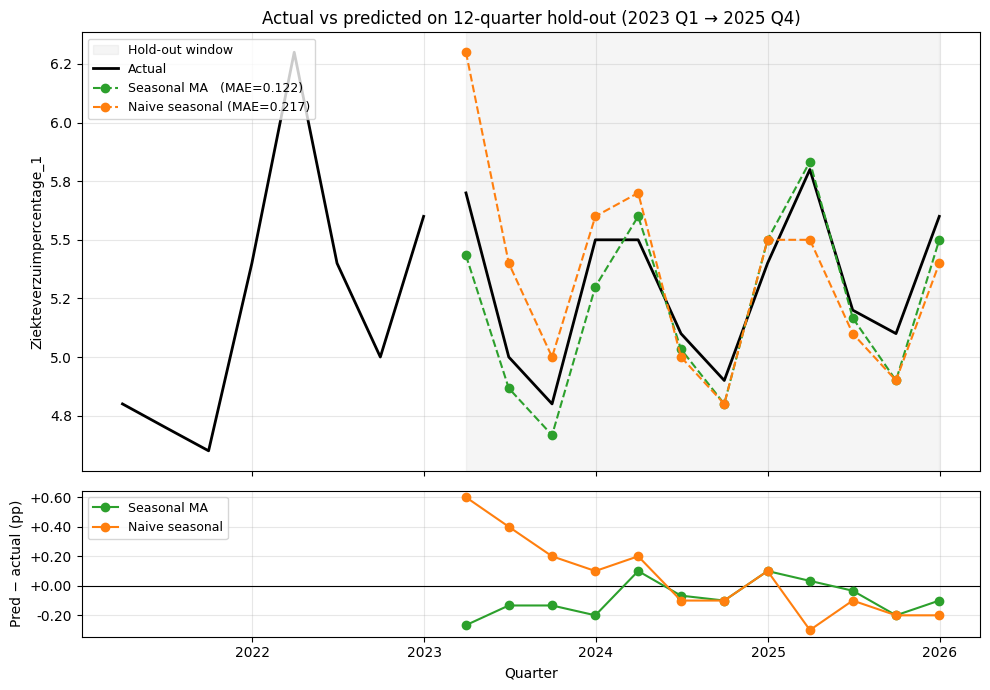

In [20]:
LOOKBACK = 8  # quarters of pre-hold-out context shown alongside the predictions

hist = y_full.iloc[-(TEST_SIZE + LOOKBACK):-TEST_SIZE]

mae_sma   = float(np.mean(np.abs(y_pred_sma.values   - y_test.values)))
mae_naive = float(np.mean(np.abs(y_pred_naive.values - y_test.values)))

q_start = f"{y_test.index.min().year} Q{((y_test.index.min().month - 1) // 3) + 1}"
q_end   = f"{y_test.index.max().year} Q{((y_test.index.max().month - 1) // 3) + 1}"

fig, (ax_top, ax_bot) = plt.subplots(
    2, 1, figsize=(10, 7), sharex=True,
    gridspec_kw={"height_ratios": [3, 1]},
)

# ── Top: actuals (with lookback) + predictions ──
ax_top.axvspan(y_test.index.min(), y_test.index.max(), color="gray", alpha=0.08, label="Hold-out window")
ax_top.plot(hist.index,   hist.values,   color="black",      linewidth=2)
ax_top.plot(y_test.index, y_test.values, color="black",      linewidth=2, label="Actual")
ax_top.plot(y_test.index, y_pred_sma.values,   color="tab:green",  linestyle="--", marker="o", label=f"Seasonal MA   (MAE={mae_sma:.3f})")
ax_top.plot(y_test.index, y_pred_naive.values, color="tab:orange", linestyle="--", marker="o", label=f"Naive seasonal (MAE={mae_naive:.3f})")

ax_top.set_title(f"Actual vs predicted on {len(y_test)}-quarter hold-out ({q_start} → {q_end})")
ax_top.set_ylabel(ML_TARGET_COLUMN)
ax_top.yaxis.set_major_formatter(mticker.FormatStrFormatter("%.1f"))
ax_top.legend(loc="upper left", fontsize=9)
ax_top.grid(True, alpha=0.3)

# ── Bottom: residuals on the hold-out ──
ax_bot.axhline(0, color="black", linewidth=0.8)
ax_bot.plot(y_test.index, y_pred_sma.values   - y_test.values, color="tab:green",  marker="o", label="Seasonal MA")
ax_bot.plot(y_test.index, y_pred_naive.values - y_test.values, color="tab:orange", marker="o", label="Naive seasonal")
ax_bot.set_ylabel("Pred − actual (pp)")
ax_bot.set_xlabel("Quarter")
ax_bot.yaxis.set_major_formatter(mticker.FormatStrFormatter("%+.2f"))
ax_bot.grid(True, alpha=0.3)
ax_bot.legend(loc="upper left", fontsize=9)

plt.tight_layout()
plt.show()

## 10 · Conclusion and 2026 forecasts

### 10.1 What the comparison tells us

On the 12-quarter hold-out, **Model A (3-year seasonal moving average) clearly outperforms Model B (1-year naive seasonal)** on every metric:

| Metric | Model A | Model B | Improvement |
|---|---|---|---|
| MAE  | 0.122 | 0.217 | ~44 % lower |
| RMSE | 0.139 | 0.261 | ~47 % lower |
| R²   | 0.802 | 0.305 | 2.6× more variance explained |

The mechanism behind the gap is concrete: the 2022 sickness-absence rate was anomalously high (post-COVID rebound, 6.3 pp at Q1). Model B carries that 2022 value forward as 100 % of its 2023 prediction (predicted 6.3 vs actual 5.7 at Q1 2023), while Model A dilutes the spike to one-third by averaging in 2020 and 2021. As the hold-out moves into 2025, both models use similar windows of post-COVID data and their residuals converge — visible in §9's residual panel.

**Bottom line: treat Model A as the primary baseline.** Model B remains useful as a sanity check; if the two ever diverge sharply on a new forecast, that's a signal worth investigating.

### 10.2 Forecasts for 2026 Q1 – Q3

We apply both models to the three quarters that follow the end of `y_full` (which stops at 2025 Q4). Each forecast uses only actuals already in `y_full`, so the formula is identical to what was evaluated on the hold-out — Model A averages the same quarter in 2023 / 2024 / 2025, Model B copies the same quarter from 2025.

In [21]:
# ── 2026 Q1–Q3 forecasts ──
# Extend y_full with NaN-valued rows for the three forecast quarters,
# then reuse the same lag/shift logic from §6 and §7. This guarantees
# the forecast formula is byte-identical to what was evaluated on the hold-out.
forecast_dates = pd.DatetimeIndex(
    ["2026-03-31", "2026-06-30", "2026-09-30"],
    name=y_full.index.name,
)
y_extended = pd.concat([
    y_full,
    pd.Series([np.nan] * len(forecast_dates), index=forecast_dates, name=y_full.name),
])

sma_forecast = (
    pd.concat([y_extended.shift(k) for k in LAGS_SMA], axis=1)
      .mean(axis=1)
      .loc[forecast_dates]
)
naive_forecast = y_extended.shift(4).loc[forecast_dates]

forecast = pd.DataFrame(
    {"Model A — Seasonal MA": sma_forecast.values,
     "Model B — Naive":       naive_forecast.values},
    index=forecast_dates,
).round(3)

print("2026 Q1–Q3 forecasts (% sickness-absence):")
print(forecast.to_string())

2026 Q1–Q3 forecasts (% sickness-absence):
                Model A — Seasonal MA  Model B — Naive
period_enddate                                        
2026-03-31                      5.667              5.8
2026-06-30                      5.100              5.2
2026-09-30                      4.933              5.1


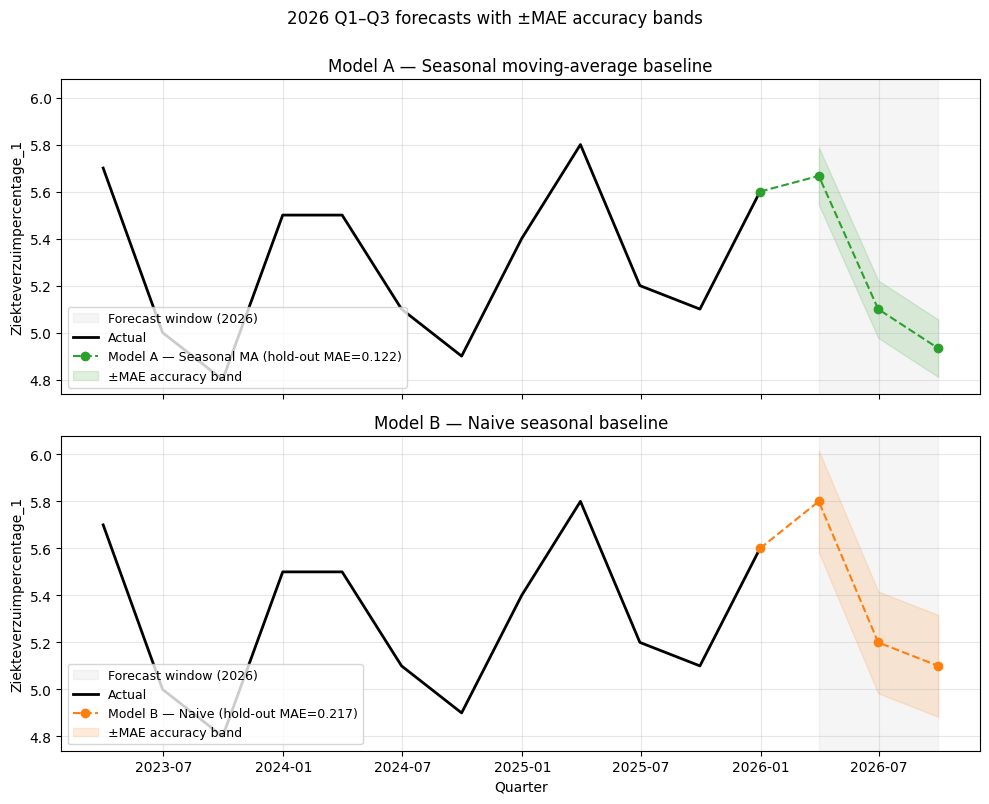

In [22]:
# ── 2026 forecast plots with ±MAE accuracy bands (one per model) ──
# Bands are sized by each model's hold-out MAE (its observed "average absolute
# miss" on 2023–2025) — a concrete, model-specific indicator of how far the
# 2026 forecast point could plausibly be from the eventual actual.
# Both panels share the y-axis so band widths can be compared visually.
LOOKBACK_PLOT = 12  # quarters of recent actuals shown for context

mae_sma   = float(np.mean(np.abs(y_pred_sma.values   - y_test.values)))
mae_naive = float(np.mean(np.abs(y_pred_naive.values - y_test.values)))

hist_plot = y_full.iloc[-LOOKBACK_PLOT:]

# Bridge from the last actual to the first forecast so the lines aren't disjoint
bridge_x = pd.DatetimeIndex([hist_plot.index[-1], *forecast_dates])
sma_y    = np.concatenate([[hist_plot.iloc[-1]], sma_forecast.values])
naive_y  = np.concatenate([[hist_plot.iloc[-1]], naive_forecast.values])

fig, (ax_a, ax_b) = plt.subplots(2, 1, figsize=(10, 8), sharex=True, sharey=True)

# ── Top: Actuals vs Model A ──
ax_a.axvspan(forecast_dates[0], forecast_dates[-1], color="gray", alpha=0.08, label="Forecast window (2026)")
ax_a.plot(hist_plot.index, hist_plot.values, color="black", linewidth=2, label="Actual")
ax_a.plot(bridge_x, sma_y, color="tab:green", linestyle="--", marker="o",
          label=f"Model A — Seasonal MA (hold-out MAE={mae_sma:.3f})")
ax_a.fill_between(forecast_dates,
                  sma_forecast.values - mae_sma,
                  sma_forecast.values + mae_sma,
                  color="tab:green", alpha=0.15, label="±MAE accuracy band")
ax_a.set_title("Model A — Seasonal moving-average baseline")
ax_a.set_ylabel(ML_TARGET_COLUMN)
ax_a.yaxis.set_major_formatter(mticker.FormatStrFormatter("%.1f"))
ax_a.legend(loc="lower left", fontsize=9)
ax_a.grid(True, alpha=0.3)

# ── Bottom: Actuals vs Model B ──
ax_b.axvspan(forecast_dates[0], forecast_dates[-1], color="gray", alpha=0.08, label="Forecast window (2026)")
ax_b.plot(hist_plot.index, hist_plot.values, color="black", linewidth=2, label="Actual")
ax_b.plot(bridge_x, naive_y, color="tab:orange", linestyle="--", marker="o",
          label=f"Model B — Naive (hold-out MAE={mae_naive:.3f})")
ax_b.fill_between(forecast_dates,
                  naive_forecast.values - mae_naive,
                  naive_forecast.values + mae_naive,
                  color="tab:orange", alpha=0.15, label="±MAE accuracy band")
ax_b.set_title("Model B — Naive seasonal baseline")
ax_b.set_ylabel(ML_TARGET_COLUMN)
ax_b.set_xlabel("Quarter")
ax_b.yaxis.set_major_formatter(mticker.FormatStrFormatter("%.1f"))
ax_b.legend(loc="lower left", fontsize=9)
ax_b.grid(True, alpha=0.3)

fig.suptitle("2026 Q1–Q3 forecasts with ±MAE accuracy bands", y=1.00, fontsize=12)
plt.tight_layout()
plt.show()

**Reading the forecasts.**

Both models predict the familiar quarterly pattern — Q1 highest (winter respiratory illness, holiday season), Q3 lowest (summer), Q2 in between:

| Quarter | Model A | Model B |
|---|---|---|
| 2026 Q1 | 5.667 | 5.800 |
| 2026 Q2 | 5.100 | 5.200 |
| 2026 Q3 | 4.933 | 5.100 |

- **Model A's forecasts are slightly more conservative.** For Q1 in particular: Model A averages 2025 Q1 (5.8), 2024 Q1 (5.5) and 2023 Q1 (5.7) to land on 5.67; Model B copies only 2025 Q1 at 5.8.
- **For Q2 and Q3 the models are within 0.1–0.2 pp** of each other, because the same-quarter values are stable across the recent three years.
- **Use Model A's numbers (5.67 / 5.10 / 4.93) as the headline forecast** given its considerably better hold-out performance. Model B's numbers (5.80 / 5.20 / 5.10) are a useful upper-bound sanity check — both models agreeing on the seasonal shape gives some confidence in the direction even if the exact level is uncertain.

These are **baseline** forecasts — they ignore everything except the target's own seasonal history. Any model that incorporates exogenous predictors (demographics, weather, labour-market signals, etc.) should be evaluated against the Model A numbers above before claiming an improvement.